# 06生成图片和BI数据表

## 1 读取数据和统一样本

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
from pathlib import Path

DATA_DIR = Path("../data_clean")
OUTPUT_DIR = Path("../outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
BI_DIR = OUTPUT_DIR / "bi"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
BI_DIR.mkdir(parents=True, exist_ok=True)

order_base = pd.read_csv(DATA_DIR / "order_base.csv")

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in date_cols:
    order_base[col] = pd.to_datetime(order_base[col], errors="coerce")

In [2]:
bi_base = order_base.copy()

bi_base["order_month"] = (
    bi_base["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

bi_base["order_month_date"] = (
    bi_base["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

bi_base["is_sales_sample"] = (
    (bi_base["order_status"] == "delivered")
    & bi_base["payment_total"].notna()
    & bi_base["price_total"].notna()
    & bi_base["freight_total"].notna()
).astype(int)

bi_base["is_delivery_review_sample"] = (
    (bi_base["order_status"] == "delivered")
    & bi_base["delivery_days"].notna()
    & bi_base["delay_days"].notna()
    & bi_base["review_score"].notna()
).astype(int)

bi_base["is_risk_sample"] = (
    (bi_base["is_sales_sample"] == 1)
    & (bi_base["is_delivery_review_sample"] == 1)
).astype(int)

delivery_sample = bi_base["is_delivery_review_sample"] == 1
risk_sample = bi_base["is_risk_sample"] == 1

bi_base["delivery_status"] = pd.NA
bi_base.loc[delivery_sample, "delivery_status"] = np.where(
    bi_base.loc[delivery_sample, "delay_days"] > 0,
    "late",
    "on_time_or_early",
)

bi_base["is_late"] = pd.NA
bi_base["is_one_star"] = pd.NA
bi_base["is_low_score"] = pd.NA

bi_base.loc[delivery_sample, "is_late"] = (
    bi_base.loc[delivery_sample, "delay_days"] > 0
)
bi_base.loc[delivery_sample, "is_one_star"] = (
    bi_base.loc[delivery_sample, "review_score"] == 1
)
bi_base.loc[delivery_sample, "is_low_score"] = (
    bi_base.loc[delivery_sample, "review_score"] <= 2
)

bi_base["is_late_int"] = pd.NA
bi_base["is_one_star_int"] = pd.NA
bi_base["is_low_score_int"] = pd.NA

bi_base.loc[delivery_sample, "is_late_int"] = (
    bi_base.loc[delivery_sample, "is_late"].astype(int)
)
bi_base.loc[delivery_sample, "is_one_star_int"] = (
    bi_base.loc[delivery_sample, "is_one_star"].astype(int)
)
bi_base.loc[delivery_sample, "is_low_score_int"] = (
    bi_base.loc[delivery_sample, "is_low_score"].astype(int)
)

bi_base[["is_late_int", "is_one_star_int", "is_low_score_int"]] = (
    bi_base[["is_late_int", "is_one_star_int", "is_low_score_int"]]
    .astype("Int64")
)

bi_base["delivery_risk_level"] = pd.NA
bi_base.loc[risk_sample, "delivery_risk_level"] = pd.cut(
    bi_base.loc[risk_sample, "delay_days"],
    bins=[-np.inf, 0, 3, 7, np.inf],
    labels=[
        "low_risk_on_time_or_early",
        "medium_risk_late_0_3d",
        "high_risk_late_3_7d",
        "critical_risk_late_7d_plus",
    ],
).astype(object)

bi_base["delay_group"] = pd.NA
bi_base.loc[delivery_sample, "delay_group"] = pd.cut(
    bi_base.loc[delivery_sample, "delay_days"],
    bins=[-np.inf, 0, 1, 3, 7, 14, np.inf],
    labels=[
        "on_time_or_early",
        "late_0_1d",
        "late_1_3d",
        "late_3_7d",
        "late_7_14d",
        "late_14d_plus",
    ],
).astype(object)

bi_base.to_csv(BI_DIR / "bi_order_base.csv", index=False)


## 2 导出月度GMV趋势图

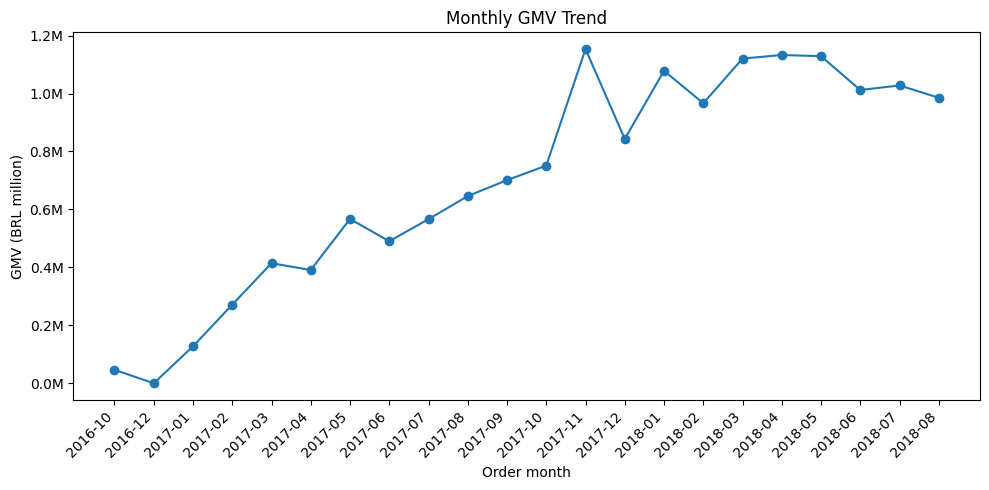

In [3]:
monthly_sales = (
    bi_base[bi_base["is_sales_sample"] == 1]
    .groupby("order_month", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        gmv=("payment_total", "sum"),
    )
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_sales["order_month"], monthly_sales["gmv"], marker="o")
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value / 1_000_000:.1f}M")
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Order month")
plt.ylabel("GMV (BRL million)")
plt.title("Monthly GMV Trend")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_monthly_gmv_trend.png", dpi=150)
plt.show()


## 3 导出支付方式GMV占比横向条形图

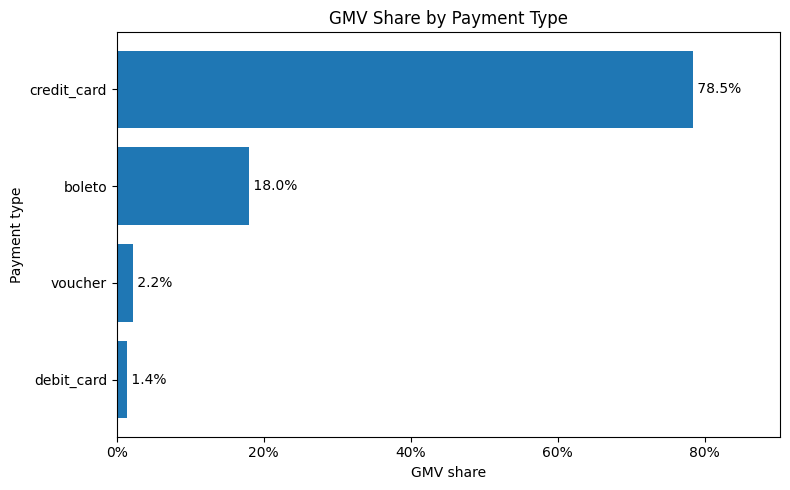

In [4]:
payment_mix = (
    bi_base[bi_base["is_sales_sample"] == 1]
    .groupby("main_payment_type", as_index=False)
    .agg(gmv=("payment_total", "sum"))
    .sort_values("gmv", ascending=True)
)

payment_mix["gmv_share"] = payment_mix["gmv"] / payment_mix["gmv"].sum()

fig, ax = plt.subplots(figsize=(8, 5))

bars = plt.barh(
    payment_mix["main_payment_type"],
    payment_mix["gmv_share"],
)

ax.xaxis.set_major_formatter(PercentFormatter(1.0))
plt.xlabel("GMV share")
plt.ylabel("Payment type")
plt.title("GMV Share by Payment Type")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {width:.1%}",
        va="center",
    )

plt.xlim(0, payment_mix["gmv_share"].max() * 1.15)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "02_payment_gmv_share_barh.png",
    dpi=150,
)
plt.show()


## 4 导出Top10州GMV横向条形图

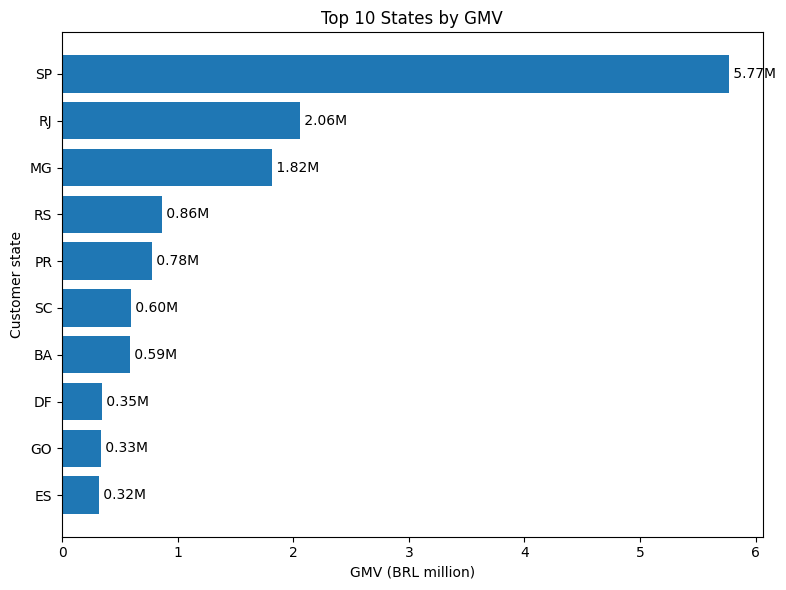

In [5]:
top_states = (
    bi_base[bi_base["is_sales_sample"] == 1]
    .groupby("customer_state", as_index=False)
    .agg(gmv=("payment_total", "sum"))
    .sort_values("gmv", ascending=False)
    .head(10)
    .sort_values("gmv", ascending=True)
)

top_states["gmv_million"] = top_states["gmv"] / 1_000_000

plt.figure(figsize=(8, 6))
plt.barh(top_states["customer_state"], top_states["gmv_million"])
plt.xlabel("GMV (BRL million)")
plt.ylabel("Customer state")
plt.title("Top 10 States by GMV")

for i, value in enumerate(top_states["gmv_million"]):
    plt.text(
        value,
        i,
        f" {value:.2f}M",
        va="center",
    )

plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_top10_state_gmv_barh.png", dpi=150)
plt.show()


## 5 导出延迟分层1星差评率折线图

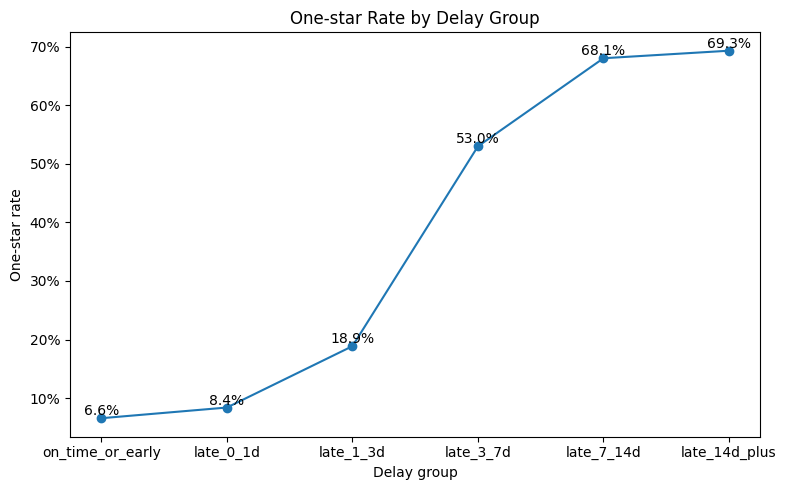

In [6]:
delay_plot = (
    bi_base[bi_base["is_delivery_review_sample"] == 1]
    .groupby("delay_group", observed=True, as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        one_star_rate=("is_one_star", "mean"),
    )
)

order = [
    "on_time_or_early",
    "late_0_1d",
    "late_1_3d",
    "late_3_7d",
    "late_7_14d",
    "late_14d_plus",
]

delay_plot["delay_group"] = pd.Categorical(
    delay_plot["delay_group"].astype(str),
    categories=order,
    ordered=True,
)

delay_plot = delay_plot.sort_values("delay_group")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    delay_plot["delay_group"],
    delay_plot["one_star_rate"],
    marker="o",
)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xlabel("Delay group")
plt.ylabel("One-star rate")
plt.title("One-star Rate by Delay Group")

for x, y in zip(delay_plot["delay_group"], delay_plot["one_star_rate"]):
    plt.text(x, y, f"{y:.1%}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_delay_group_one_star_rate_line.png", dpi=150)
plt.show()


## 6 导出地区风险气泡图

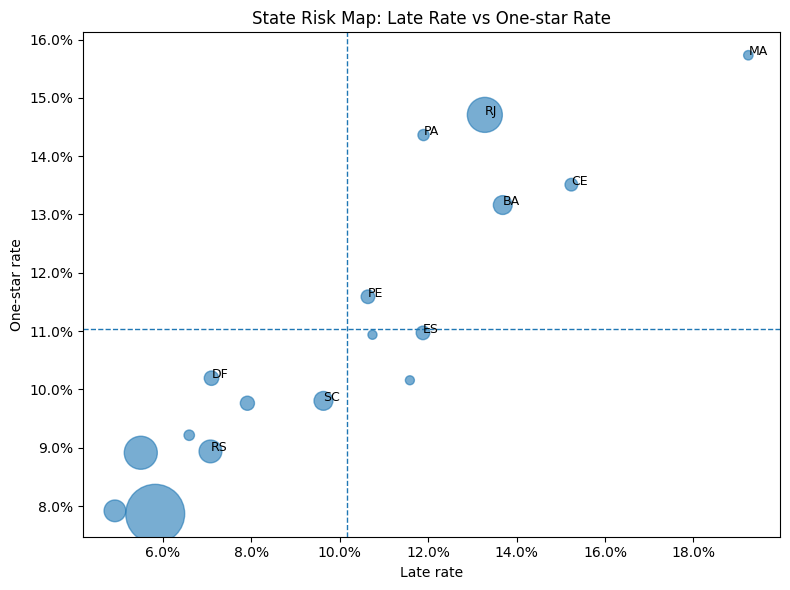

In [7]:
state_risk = (
    bi_base[bi_base["is_risk_sample"] == 1]
    .groupby("customer_state", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        gmv=("payment_total", "sum"),
        late_rate=("is_late", "mean"),
        one_star_rate=("is_one_star", "mean"),
    )
)

state_risk = state_risk[state_risk["orders"] >= 500].copy()
state_risk["gmv_rank"] = state_risk["gmv"].rank(
    ascending=False,
    method="min",
)
state_risk["late_rate_rank"] = state_risk["late_rate"].rank(
    ascending=False,
    method="min",
)
state_risk["one_star_rate_rank"] = state_risk["one_star_rate"].rank(
    ascending=False,
    method="min",
)
state_risk["priority_score"] = (
    state_risk["gmv_rank"]
    + state_risk["late_rate_rank"]
    + state_risk["one_star_rate_rank"]
)
state_risk["bubble_size"] = state_risk["gmv"] / state_risk["gmv"].max() * 1800

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    state_risk["late_rate"],
    state_risk["one_star_rate"],
    s=state_risk["bubble_size"],
    alpha=0.6,
)

ax.axvline(state_risk["late_rate"].mean(), linestyle="--", linewidth=1)
ax.axhline(state_risk["one_star_rate"].mean(), linestyle="--", linewidth=1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

for _, row in state_risk.sort_values("priority_score").head(10).iterrows():
    plt.text(
        row["late_rate"],
        row["one_star_rate"],
        row["customer_state"],
        fontsize=9,
    )

plt.xlabel("Late rate")
plt.ylabel("One-star rate")
plt.title("State Risk Map: Late Rate vs One-star Rate")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_state_risk_scatter.png", dpi=150)
plt.show()
